# Introduction to Deep Learning.

We move from classic classifiers to deep learning based architectures. In this practical session we will cover:
- How to implement a simple neural network using PyTorch.
- How to train a neural network and check different optimization strategies.
- Review the concept of overfitting and how to avoid it using regularization techniques.

In [4]:
# Let's start by importing torch
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

torch.manual_seed(0)

# Get the MNIST dataset
# Set up the data preprocessing and loading:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])  # transform the data to torch tensor and normalize
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Now let's split the training set into a training and validation set
generator = torch.Generator().manual_seed(42)  # just a random generator
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [50000, 10000], generator=generator)

print('We loaded {} training, {} validation, and {} testing samples'.format(len(train_dataset), len(val_dataset), len(test_dataset)))

# Set up the data loaders (they are iterable objects that return the data in batches)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

We loaded 50000 training, 10000 validation, and 10000 testing samples


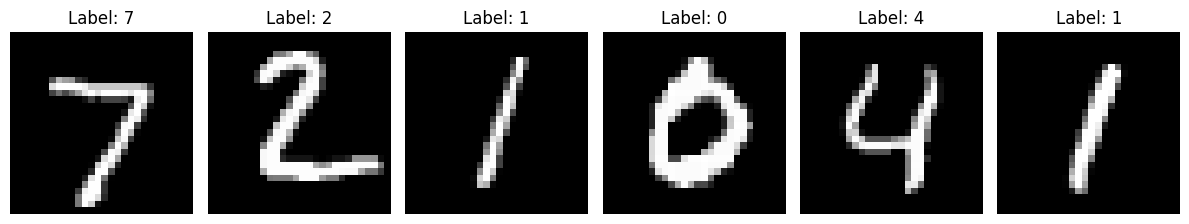

In [5]:
# Visualize some of the data
import matplotlib.pyplot as plt
import numpy as np

# Exercise 1: Visualize the first 6 images and their labels from the test set

fig, axes = plt.subplots(1, 6, figsize=(12, 3))
for i in range(6):
    img, label = test_dataset[i]
    # Unnormalize from [-1, 1] to [0, 1] for display
    img = img * 0.5 + 0.5
    axes[i].imshow(img.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Exercise 2: what is the size of the input images? If we want to use a fully connected layer, what is the size of the input of the fully connected layer?

In [6]:
# Let's define the neural network architecture to learn how to classify the images
import torch.nn as nn

# Define the model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        return self.fc3(x)  # raw logits -- nn.CrossEntropyLoss applies log-softmax internally

print(Net())

Net(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu1): ReLU()
  (relu2): ReLU()
)


**Note on the loss:** `nn.CrossEntropyLoss` (used below) already combines `log_softmax` followed by negative log-likelihood in one numerically-stable step, so the model above returns raw, unnormalized scores (logits) rather than log-probabilities. If `forward` also applied `LogSoftmax` (as an earlier version of this notebook did) while still using `CrossEntropyLoss`, log-softmax would be applied *twice* — silently distorting the loss landscape, since the second log-softmax operates on numbers that are already log-probabilities. Only ever pair `LogSoftmax` with `NLLLoss`, *or* raw logits with `CrossEntropyLoss` — never mix the two.

### Exercise 3: Draw a schematic representation of the model, how many trainable parameters does it have?

In [7]:
# Let's visualize the model graph with tensorboard
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter("torchlogs/")
model = Net()
images, labels = next(iter(test_loader))
writer.add_graph(model, images)
writer.close()

**Tip:** to open TensorBoard and inspect the logs written above (and throughout this notebook), run in a new cell:
```
%load_ext tensorboard
%tensorboard --logdir torchlogs
```
(or, from a terminal in this folder: `tensorboard --logdir torchlogs`). We leave this as a markdown note rather than a live cell so that batch-executing this notebook doesn't spawn a background TensorBoard server.

## Now let's train the model

All training in this notebook runs on CPU by design — this is a small MLP on MNIST, so it comfortably fits the class-time budget. If you have a GPU/MPS device available and want to use it, move the model and batches with the standard idiom: `device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")`, then `model.to(device)` and `images, labels = images.to(device), labels.to(device)`.

In [8]:
# Now let's train the model
import torch.optim as optim

num_epochs = 5  # an epoch is a full pass through the dataset (each step is one batch, once we used all the batches we have completed an epoch)
model = Net()  # init the network
criterion = nn.CrossEntropyLoss()  # define the loss function as the cross entropy loss
optimizer = optim.SGD(model.parameters(), lr=0.01)  # define the optimizer (in this case stochastic gradient descent)

for epoch in range(num_epochs):
    model.train()  # set the model to training mode
    for batch_idx, (images, labels) in enumerate(train_loader):  # Iterate over the batches
        optimizer.zero_grad()  # zero the gradients (otherwise they accumulate)
        output = model(images)  # forward pass (compute the output)
        loss = criterion(output, labels)  # compute the loss
        loss.backward()  # backward pass (compute the gradients and do backpropagation)
        optimizer.step()  # update the weights (do one step of optimization)

        if batch_idx % 100 == 0:  # print some information every 100 batches
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch+1, batch_idx * len(images), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.301153
Train Epoch: 1 [6400/50000 (13%)]	Loss: 2.149711
Train Epoch: 1 [12800/50000 (26%)]	Loss: 1.881266
Train Epoch: 1 [19200/50000 (38%)]	Loss: 1.284410
Train Epoch: 1 [25600/50000 (51%)]	Loss: 0.908599
Train Epoch: 1 [32000/50000 (64%)]	Loss: 0.705302
Train Epoch: 1 [38400/50000 (77%)]	Loss: 0.607247
Train Epoch: 1 [44800/50000 (90%)]	Loss: 0.641488
Train Epoch: 2 [0/50000 (0%)]	Loss: 0.696714
Train Epoch: 2 [6400/50000 (13%)]	Loss: 0.515710
Train Epoch: 2 [12800/50000 (26%)]	Loss: 0.362128
Train Epoch: 2 [19200/50000 (38%)]	Loss: 0.397720
Train Epoch: 2 [25600/50000 (51%)]	Loss: 0.473600
Train Epoch: 2 [32000/50000 (64%)]	Loss: 0.299510
Train Epoch: 2 [38400/50000 (77%)]	Loss: 0.539612
Train Epoch: 2 [44800/50000 (90%)]	Loss: 0.197680
Train Epoch: 3 [0/50000 (0%)]	Loss: 0.312605
Train Epoch: 3 [6400/50000 (13%)]	Loss: 0.374899
Train Epoch: 3 [12800/50000 (26%)]	Loss: 0.445411
Train Epoch: 3 [19200/50000 (38%)]	Loss: 0.401900
Train Epoch: 3 [25

### Let's do the same but using tensorboard to visualize the training process.

In [9]:
# Let's repeat the training but using tensorboard to log the loss
writer = SummaryWriter("torchlogs/experiment_loss")

num_epochs = 5  # an epoch is a full pass through the dataset (each step is one batch, once we used all the batches we have completed an epoch)
model = Net()  # init the network
criterion = nn.CrossEntropyLoss()  # define the loss function as the cross entropy loss
optimizer = optim.SGD(model.parameters(), lr=0.01)  # define the optimizer (in this case stochastic gradient descent)

for epoch in range(num_epochs):
    model.train()  # set the model to training mode
    for batch_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()  # zero the gradients
        output = model(images)  # forward pass
        loss = criterion(output, labels)  # compute the loss
        loss.backward()  # backward pass
        optimizer.step()  # update the weights

        if batch_idx % 100 == 0:
            writer.add_scalar('training loss', loss.item(), epoch*len(train_loader)+batch_idx)

writer.close()

### Exercise 4: Repeat the training process, but now report the accuracy on the training and the validation set. 

**Note:** `compute_model_accuracy` below switches the model to `eval()` before scoring and back to `train()` afterward, because layers like dropout and batch normalization behave differently during training vs. evaluation (e.g. dropout is disabled at eval time) — always evaluate in `eval()` mode for a reproducible accuracy readout. The model above doesn't have such layers yet, but this will matter a lot once we add dropout in Exercise 6.

In [10]:
# Let's repeat the training but using tensorboard to log the loss and accuracy
writer = SummaryWriter("torchlogs/experiment_ex4")

num_epochs = 10  # an epoch is a full pass through the dataset (each step is one batch, once we used all the batches we have completed an epoch)
model = Net()  # init the network
criterion = nn.CrossEntropyLoss()  # define the loss function as the cross entropy loss
optimizer = optim.SGD(model.parameters(), lr=0.01)  # define the optimizer (in this case stochastic gradient descent)


# Exercise 4: report the accuracy on the training and validation set
# TODO: your code here

for epoch in range(num_epochs):
    model.train()  # set the model to training mode
    for batch_idx, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()  # zero the gradients
        output = model(images)  # forward pass
        loss = criterion(output, labels)  # compute the loss
        loss.backward()  # backward pass
        optimizer.step()  # update the weights

        if batch_idx % 100 == 0:  # log train loss every 100 batches
            writer.add_scalar('training loss', loss.item(), epoch*len(train_loader)+batch_idx)

    # TODO: your code here

writer.close()

# TODO: your code here

### Exercise 5: Compare the performance if you use only 100, 500, 1000, 5000, and 50000 samples for training. Do any of these models overfit?
### Exercise 6: Add dropout layers and L2 regularization to avoid overfitting and repeat Exercise 5's experiments. Comment on the observed results. 

**Runtime note:** the sweep below trains 2 model variants x 5 training-set sizes = 10 models from scratch. A fixed number of *epochs* would give the 100-sample run only ~2 gradient steps per epoch (100 samples / 64 batch size) — nowhere near enough to fit anything, let alone overfit. Instead we fix the number of gradient *steps* per run and derive each size's epoch count from it, so every subset size gets a comparable amount of training; this also keeps the sweep well within class time — the full Exercise 5 + 6 sweep takes under a minute on CPU on this machine.

In [13]:
# Exercise 5: compare final train/validation accuracy for different training-set sizes.
# Tip: torch.utils.data.Subset(train_dataset, indices) gives you a smaller training set; reuse
# compute_model_accuracy (defined above) to score each resulting model.
# TODO: your code here
def compute_model_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    model.train()
    return 100.0 * correct / total
sizes = [100, 500, 1000, 5000, 50000]
target_steps = 1500  # Step-equalized training budget
results_ex5 = {}
for size in sizes:
    subset = torch.utils.data.Subset(train_dataset, range(size))
    batch_size = min(64, size)
    subset_loader = DataLoader(subset, batch_size=batch_size, shuffle=True)
    
    epochs = max(10, target_steps // len(subset_loader))
    model = Net()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)
    
    for epoch in range(epochs):
        model.train()
        for images, labels in subset_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    train_acc = compute_model_accuracy(model, subset_loader)
    val_acc = compute_model_accuracy(model, val_loader)
    results_ex5[size] = (train_acc, val_acc)
    print(f"Size: {size:5d} | Train Acc: {train_acc:6.2f}% | Val Acc: {val_acc:6.2f}% | Gap: {train_acc - val_acc:6.2f}%")

Size:   100 | Train Acc: 100.00% | Val Acc:  72.55% | Gap:  27.45%
Size:   500 | Train Acc:  98.80% | Val Acc:  84.64% | Gap:  14.16%
Size:  1000 | Train Acc:  95.00% | Val Acc:  86.55% | Gap:   8.45%
Size:  5000 | Train Acc:  88.76% | Val Acc:  87.81% | Gap:   0.95%
Size: 50000 | Train Acc:  94.32% | Val Acc:  93.37% | Gap:   0.95%


In [14]:
# Exercise 6: add dropout + L2 (weight decay) regularization and repeat the Exercise 5 sweep,
# using the same step-equalized epoch schedule so the comparison stays apples-to-apples.
# Regularized network architecture with Dropout
class NetRegularized(nn.Module):
    def __init__(self, p=0.5):
        super(NetRegularized, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()
        self.drop1 = nn.Dropout(p=p)
        self.drop2 = nn.Dropout(p=p)
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.drop1(self.relu1(self.fc1(x)))
        x = self.drop2(self.relu2(self.fc2(x)))
        return self.fc3(x)
results_ex6 = {}
for size in sizes:
    subset = torch.utils.data.Subset(train_dataset, range(size))
    batch_size = min(64, size)
    subset_loader = DataLoader(subset, batch_size=batch_size, shuffle=True)
    
    epochs = max(10, target_steps // len(subset_loader))
    model = NetRegularized(p=0.2)
    criterion = nn.CrossEntropyLoss()
    # L2 regularization via weight_decay
    optimizer = optim.SGD(model.parameters(), lr=0.01, weight_decay=1e-4)
    
    for epoch in range(epochs):
        model.train()
        for images, labels in subset_loader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
    train_acc = compute_model_accuracy(model, subset_loader)
    val_acc = compute_model_accuracy(model, val_loader)
    results_ex6[size] = (train_acc, val_acc)
    print(f"Size: {size:5d} | Train Acc: {train_acc:6.2f}% | Val Acc: {val_acc:6.2f}% | Gap: {train_acc - val_acc:6.2f}%")

Size:   100 | Train Acc: 100.00% | Val Acc:  72.50% | Gap:  27.50%
Size:   500 | Train Acc:  96.80% | Val Acc:  85.32% | Gap:  11.48%
Size:  1000 | Train Acc:  93.20% | Val Acc:  86.72% | Gap:   6.48%
Size:  5000 | Train Acc:  88.20% | Val Acc:  87.21% | Gap:   0.99%
Size: 50000 | Train Acc:  94.77% | Val Acc:  93.92% | Gap:   0.85%
